# AI Water Quality Analysis and pH Prediction

**Student:** Baikani Akshitha  
**Program:** B.Tech Information Technology  
**Project:** AI Water Quality Analysis and pH Prediction

## Objective

This project analyzes historical water-quality measurements from monitoring locations and uses machine learning to predict the next-day pH target.

The project includes:

- Data loading and inspection
- Exploratory data analysis
- Data visualization
- Linear Regression
- Random Forest Regression
- Model evaluation
- Feature importance analysis
- Actual vs predicted visualization

> **Dataset Note:** The processed target values are normalized. Therefore, values such as 0.66 should not be interpreted as literal pH readings unless the original normalization parameters are available.

## Dataset

The project uses the processed `water_quality_prediction.csv` derived from the UCI Water Quality Prediction dataset.

### Dataset Characteristics

- 26,048 records
- 37 monitoring locations
- 13 input features
- 1 target variable
- No missing values

The original dataset project describes the task as forecasting water quality in terms of pH for the next day using historical water-quality measurements.

### Research Reference

Liang Zhao, Olga Gkountouna, Dieter Pfoser (2019), ACM T-SAS.

DOI: 10.1145/3339823

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import dump

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the water quality dataset

data_path = "../data/water_quality_prediction.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (26048, 14)


,date_index,location_id,specific_conductance_max,ph_max,ph_min,specific_conductance_min,specific_conductance_mean,dissolved_oxygen_max,dissolved_oxygen_mean,dissolved_oxygen_min,temperature_mean,temperature_min,temperature_max,target_ph_next_day
0,1,2198840,0.001131,0.884615,0.001120,0.001113,0.677632,0.841463,0.765152,0.787402,0.29375,0.298077,0.276163,0.648148
1,2,2198840,0.001131,0.884615,0.001120,0.001113,0.677632,0.841463,0.757576,0.779528,0.29375,0.288462,0.287791,0.648148
2,3,2198840,0.001131,0.884615,0.001120,0.001133,0.677632,0.841463,0.765152,0.779528,0.30000,0.294872,0.293605,0.648148
3,4,2198840,0.001131,0.884615,0.001139,0.001133,0.677632,0.841463,0.757576,0.779528,0.30625,0.301282,0.296512,0.648148
4,5,2198840,0.001131,0.884615,0.001139,0.001133,0.664474,0.841463,0.750000,0.771654,0.32500,0.317308,0.325581,0.638889


In [4]:
# Check dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Locations:", df["location_id"].nunique())

print("\nTarget Variable Statistics:")
print(df["target_ph_next_day"].describe())

Dataset Shape: (26048, 14)

Column Names:
['date_index', 'location_id', 'specific_conductance_max', 'ph_max', 'ph_min', 'specific_conductance_min', 'specific_conductance_mean', 'dissolved_oxygen_max', 'dissolved_oxygen_mean', 'dissolved_oxygen_min', 'temperature_mean', 'temperature_min', 'temperature_max', 'target_ph_next_day']

Missing Values:
date_index                   0
location_id                  0
specific_conductance_max     0
ph_max                       0
ph_min                       0
specific_conductance_min     0
specific_conductance_mean    0
dissolved_oxygen_max         0
dissolved_oxygen_mean        0
dissolved_oxygen_min         0
temperature_mean             0
temperature_min              0
temperature_max              0
target_ph_next_day           0
dtype: int64

Number of Locations: 37

Target Variable Statistics:
count    26048.000000
mean         0.663529
std          0.029389
min          0.574074
25%          0.648148
50%          0.657407
75%          0.67592

In [5]:
# Define input features and target variable

target_column = "target_ph_next_day"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (26048, 13)
Target shape: (26048,)

Feature columns:
['date_index', 'location_id', 'specific_conductance_max', 'ph_max', 'ph_min', 'specific_conductance_min', 'specific_conductance_mean', 'dissolved_oxygen_max', 'dissolved_oxygen_mean', 'dissolved_oxygen_min', 'temperature_mean', 'temperature_min', 'temperature_max']


In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training percentage:", len(X_train) / len(X) * 100)
print("Testing percentage:", len(X_test) / len(X) * 100)

Training samples: 20838
Testing samples: 5210
Training percentage: 79.99846437346437
Testing percentage: 20.001535626535627


In [7]:
# Train Linear Regression baseline model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

# Evaluate the model
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)    

Linear Regression Results
-------------------------
MAE : 0.02158187204343009
RMSE: 0.029506617627055993
R²  : 0.0002702547648242293


In [8]:
# Train Random Forest Regression model

random_forest_model = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 0.006949124428331092
RMSE: 0.013180086882112188
R²  : 0.8005287529917985


In [9]:
# Compare Linear Regression and Random Forest

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.021582,0.029507,0.000270
1,Random Forest,0.006949,0.013180,0.800529


In [10]:
# Save the trained Random Forest model

model_path = "../models/random_forest_water_quality.pkl"

dump(random_forest_model, model_path)

print("Random Forest model saved successfully!")
print("Location:", model_path)


Random Forest model saved successfully!
Location: ../models/random_forest_water_quality.pkl


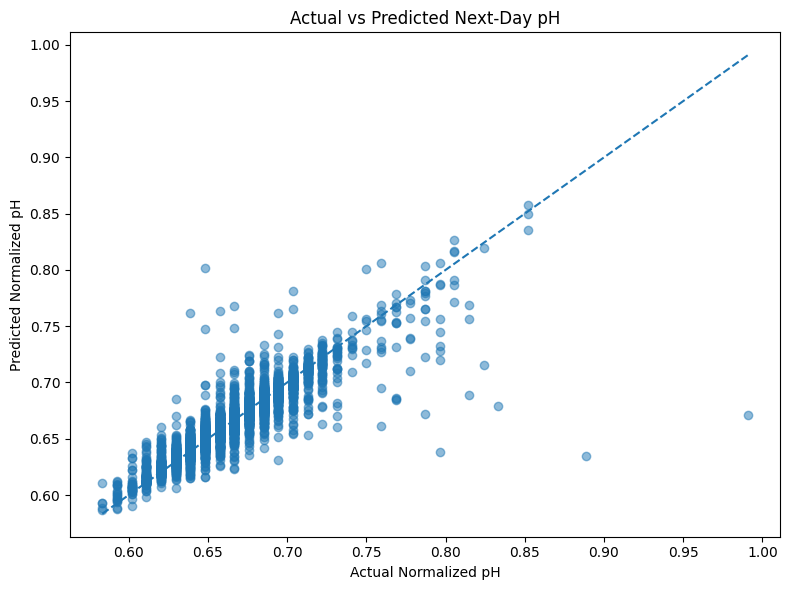

Actual vs Predicted graph saved successfully!


In [11]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

# Reference line
min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Normalized pH")
plt.ylabel("Predicted Normalized pH")
plt.title("Actual vs Predicted Next-Day pH")

plt.tight_layout()

# Save the graph
plt.savefig("../outputs/graphs/actual_vs_predicted.png", dpi=300)

plt.show()

print("Actual vs Predicted graph saved successfully!")

In [12]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
7,dissolved_oxygen_max,0.725222
6,specific_conductance_mean,0.042264
2,specific_conductance_max,0.037589
0,date_index,0.030348
4,ph_min,0.023380
1,location_id,0.022454
12,temperature_max,0.020855
5,specific_conductance_min,0.020563
3,ph_max,0.019215
9,dissolved_oxygen_min,0.016673


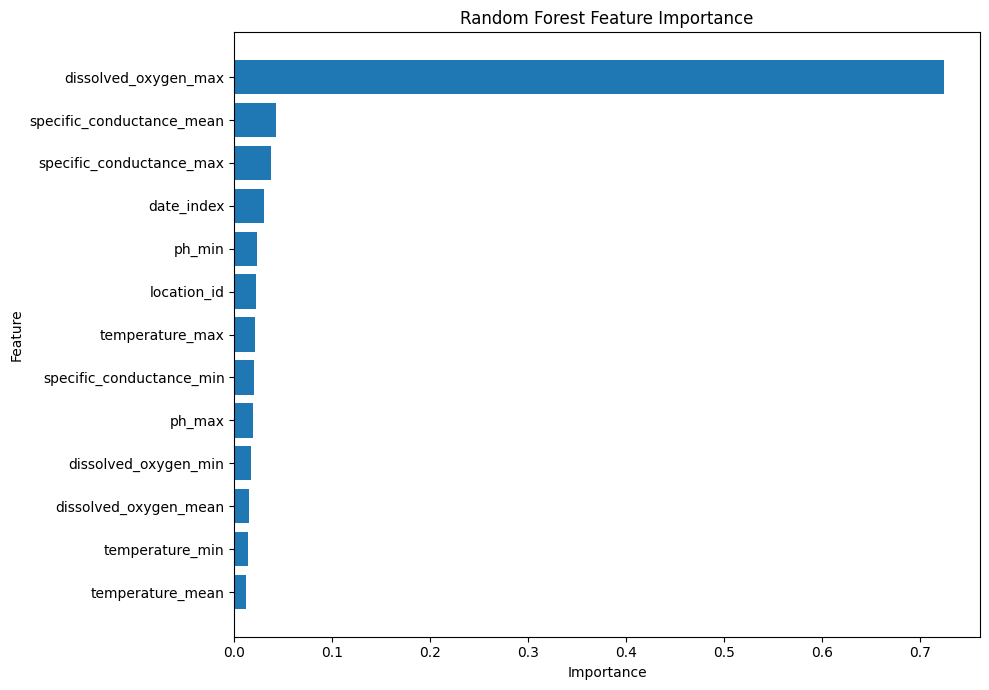

Feature importance graph saved successfully!


In [13]:
# Plot feature importance

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

# Save the graph
plt.savefig(
    "../outputs/graphs/feature_importance.png",
    dpi=300
)

plt.show()

print("Feature importance graph saved successfully!")

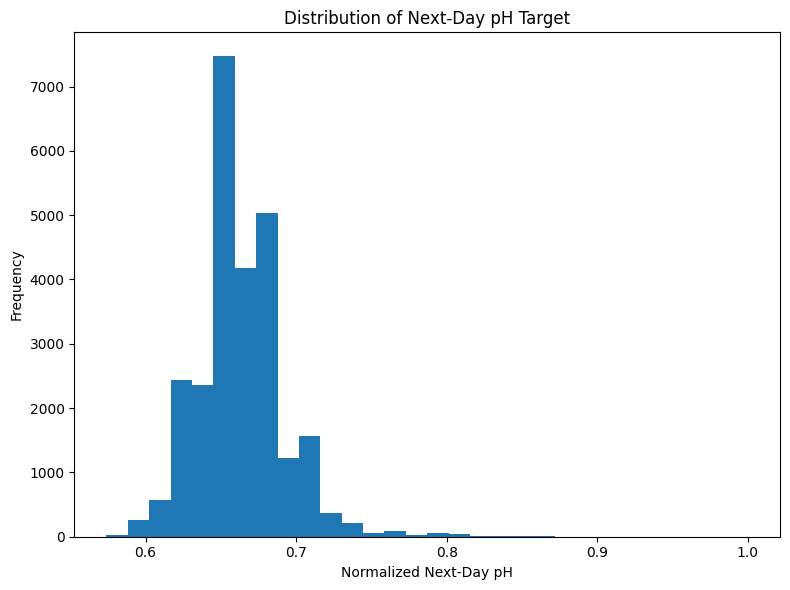

Target distribution graph saved successfully!


In [14]:
# Plot distribution of the target variable

plt.figure(figsize=(8, 6))

plt.hist(
    df["target_ph_next_day"],
    bins=30
)

plt.xlabel("Normalized Next-Day pH")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Day pH Target")

plt.tight_layout()

# Save the graph
plt.savefig(
    "../outputs/graphs/target_ph_distribution.png",
    dpi=300
)

plt.show()

print("Target distribution graph saved successfully!")

In [15]:
# Save feature importance results

feature_importance_path = "../outputs/results/feature_importance.csv"

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance results saved successfully!")
print("Location:", feature_importance_path)

Feature importance results saved successfully!
Location: ../outputs/results/feature_importance.csv


In [16]:
# Save actual and predicted values

predictions_df = pd.DataFrame({
    "Actual_Normalized_pH": y_test.values,
    "Predicted_Normalized_pH": rf_predictions
})

predictions_path = "../outputs/results/predictions.csv"

predictions_df.to_csv(
    predictions_path,
    index=False
)

print("Prediction results saved successfully!")
print("Location:", predictions_path)

predictions_df.head()

Prediction results saved successfully!
Location: ../outputs/results/predictions.csv


,Actual_Normalized_pH,Predicted_Normalized_pH
0,0.694444,0.684877
1,0.685185,0.685185
2,0.601852,0.606790
3,0.703704,0.691667
4,0.666667,0.666049


In [17]:
# Final model summary

print("=" * 55)
print("AI WATER QUALITY ANALYSIS AND pH PREDICTION")
print("=" * 55)

print("\nDataset:")
print("Total records:", len(df))
print("Number of features:", X.shape[1])
print("Monitoring locations:", df["location_id"].nunique())
print("Missing values:", df.isnull().sum().sum())

print("\nModel Performance:")
print("-" * 30)

print("\nLinear Regression:")
print(f"MAE  : {linear_mae:.6f}")
print(f"RMSE : {linear_rmse:.6f}")
print(f"R²   : {linear_r2:.6f}")

print("\nRandom Forest:")
print(f"MAE  : {rf_mae:.6f}")
print(f"RMSE : {rf_rmse:.6f}")
print(f"R²   : {rf_r2:.6f}")

print("\nMost Important Feature:")
print(feature_importance.iloc[0]["Feature"])
print(f"Importance: {feature_importance.iloc[0]['Importance']:.6f}")

print("\nOutput files generated:")
print("- Actual vs Predicted graph")
print("- Feature Importance graph")
print("- Target Distribution graph")
print("- Feature Importance CSV")
print("- Predictions CSV")
print("- Trained Random Forest model")

print("\nProject completed successfully!")

AI WATER QUALITY ANALYSIS AND pH PREDICTION

Dataset:
Total records: 26048
Number of features: 13
Monitoring locations: 37
Missing values: 0

Model Performance:
------------------------------

Linear Regression:
MAE  : 0.021582
RMSE : 0.029507
R²   : 0.000270

Random Forest:
MAE  : 0.006949
RMSE : 0.013180
R²   : 0.800529

Most Important Feature:
dissolved_oxygen_max
Importance: 0.725222

Output files generated:
- Actual vs Predicted graph
- Feature Importance graph
- Target Distribution graph
- Feature Importance CSV
- Predictions CSV
- Trained Random Forest model

Project completed successfully!


## Conclusion

This project developed an AI-based water quality analysis system for predicting
next-day normalized pH values using historical water-quality measurements from
multiple monitoring locations.

Two regression models were evaluated: Linear Regression and Random Forest
Regression. The Random Forest model achieved an MAE of 0.006949, an RMSE of
0.013180, and an R² score of 0.800529 on the test dataset.

Feature importance analysis showed that `dissolved_oxygen_max` was the most
important feature used by the Random Forest model, with an importance value of
0.725222.

The project demonstrates how machine learning can be applied to historical
water-quality data to support predictive analysis of next-day pH conditions.
The target values in this project are normalized values, so they should not be
interpreted as direct pH measurements without the original normalization
parameters.

### Key Outcomes

- Dataset analyzed: 26,048 records
- Monitoring locations: 37
- Input features: 13
- Target: Next-day normalized pH
- Best-performing model in this experiment: Random Forest Regression
- Random Forest R²: 0.800529
- Random Forest MAE: 0.006949
- Random Forest RMSE: 0.013180
- Most important feature: `dissolved_oxygen_max`